<a href="https://colab.research.google.com/github/wywy221/bcce_workshop/blob/main/20260726_workshopfile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Have students work with a data set involving HIV-1 protease binding with several inhibitors and teach about the following
1. What *K*_d (and *K*_i) mean
2. How binding affinity relates to binding *free energy* (ΔG)
3. How to compare drugs on a fair footing using **ligand efficiency**
4. How to evaluate **druglikeness** using Lipinski's Rule of Five
5. How to weigh potency vs. druglikeness to argue for the "best" drug

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
print("Libraries loaded.")

Libraries loaded.


## Section 1 — Build the Dataset

Below are 10 FDA-approved HIV-1 protease inhibitors, in order of FDA approval. For each drug we have:

| Column | Meaning |
|---|---|
| `Ki_nM` | Enzymatic inhibition constant vs. wild-type HIV-1 protease (nM); treated here as ≈ K_d |
| `MW` | Molecular weight (g/mol) |
| `LogP` | Calculated octanol-water partition coefficient (lipophilicity) |
| `HBD` | Hydrogen bond donors |
| `HBA` | Hydrogen bond acceptors |
| `RotBonds` | Number of rotatable bonds (flexibility) |
| `HeavyAtoms` | Number of non-hydrogen atoms (used for ligand efficiency) |
| `Year_Approved` | Year of FDA approval |

**Fosamprenavir** is included as a special case: it's a *prodrug* (an inactive precursor that the body converts into amprenavir). It doesn't bind the protease directly, so its `Ki_nM` is `NaN` — a good discussion point about why chemists sometimes design a drug that *isn't* the active binder!


The following is a dataset generated by AI with data pulled from various databases

In [2]:
data = [
    # Drug, Ki_nM, MW, LogP, HBD, HBA, RotBonds, HeavyAtoms, Year_Approved
    ("Saquinavir",     0.12,  670.85, 3.3, 3, 8, 13, 49, 1995),
    ("Ritonavir",      0.02,  720.94, 5.9, 3, 8, 18, 50, 1996),
    ("Indinavir",      0.36,  613.79, 2.8, 3, 5, 11, 45, 1996),
    ("Nelfinavir",     2.00,  567.78, 5.5, 3, 4, 11, 40, 1997),
    ("Amprenavir",     4.00,  505.63, 2.5, 3, 6, 10, 35, 1999),
    ("Lopinavir",      1.30,  628.80, 5.9, 4, 5, 15, 46, 2000),
    ("Atazanavir",     2.60,  704.86, 4.5, 4, 9, 15, 51, 2003),
    ("Fosamprenavir",  np.nan,585.63, 0.3, 4, 9, 12, 39, 2003),  # prodrug of amprenavir
    ("Tipranavir",     6.80,  602.67, 6.9, 3, 5, 11, 42, 2005),
    ("Darunavir",      0.045, 547.66, 1.8, 3, 7,  8, 38, 2006),
]

columns = ["Drug", "Ki_nM", "MW", "LogP", "HBD", "HBA", "RotBonds", "HeavyAtoms", "Year_Approved"]
df = pd.DataFrame(data, columns=columns)
df

,Drug,Ki_nM,MW,LogP,HBD,HBA,RotBonds,HeavyAtoms,Year_Approved
0,Saquinavir,0.120,670.85,3.3,3,8,13,49,1995
1,Ritonavir,0.020,720.94,5.9,3,8,18,50,1996
2,Indinavir,0.360,613.79,2.8,3,5,11,45,1996
3,Nelfinavir,2.000,567.78,5.5,3,4,11,40,1997
4,Amprenavir,4.000,505.63,2.5,3,6,10,35,1999
5,Lopinavir,1.300,628.80,5.9,4,5,15,46,2000
6,Atazanavir,2.600,704.86,4.5,4,9,15,51,2003
7,Fosamprenavir,NaN,585.63,0.3,4,9,12,39,2003
8,Tipranavir,6.800,602.67,6.9,3,5,11,42,2005
9,Darunavir,0.045,547.66,1.8,3,7,8,38,2006


In [11]:
# Install necessary libraries
!pip install rdkit
!pip install pubchempy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 53.8 MB/s eta 0:00:00


/tmp/ipykernel_873/3266274551.py:14: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  smiles = compounds[0].canonical_smiles
/tmp/ipykernel_873/3266274551.py:14: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  smiles = compounds[0].canonical_smiles
/tmp/ipykernel_873/3266274551.py:14: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  smiles = compounds[0].canonical_smiles


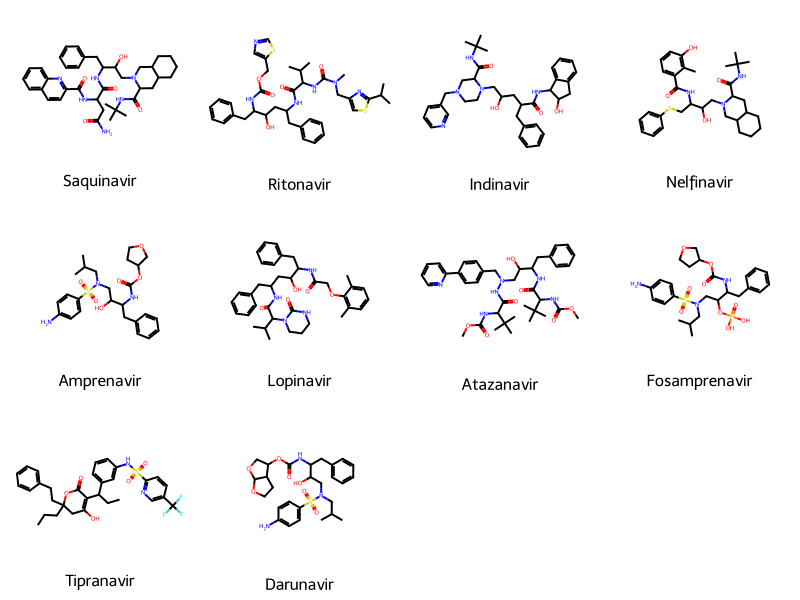

In [12]:
from rdkit import Chem
from rdkit.Chem import Draw
import pubchempy as pcp

mols = []
drug_names = []

for drug in df["Drug"]:
    try:
        # Query PubChem for the compound by name
        compounds = pcp.get_compounds(drug, 'name')
        if compounds:
            # Take the first result and get its SMILES string
            smiles = compounds[0].canonical_smiles
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                mols.append(mol)
                drug_names.append(drug)
            else:
                print(f"Could not create RDKit molecule for {drug} from SMILES: {smiles}")
        else:
            print(f"SMILES not found for {drug} in PubChem.")
    except Exception as e:
        print(f"Error processing {drug}: {e}")

# Display the structures if molecules were found
if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(200, 200), legends=drug_names)
    display(img)
else:
    print("No structures could be generated.")

## Section 2 — From K_i to pK_i and ΔG

Binding constants span many orders of magnitude, so scientists usually work with **pK_i = -log10(K_i in molar units)**, just like pH. Bigger pK_i = tighter binding (the opposite direction from K_i!).

In [3]:
R = 8.314          # J / (mol*K)
T = 310.15          # K, human body temperature (37 C)

df["Ki_M"] = df["Ki_nM"] * 1e-9              # convert nM -> M
df["pKi"] = -np.log10(df["Ki_M"])
df["dG_kJ_per_mol"] = R * T * np.log(df["Ki_M"]) / 1000

display(df[["Drug", "Ki_nM", "pKi", "dG_kJ_per_mol"]].sort_values("pKi", ascending=False))

,Drug,Ki_nM,pKi,dG_kJ_per_mol
1,Ritonavir,0.020,10.698970,-63.524238
9,Darunavir,0.045,10.346787,-61.433184
0,Saquinavir,0.120,9.920819,-58.904030
2,Indinavir,0.360,9.443697,-56.071163
5,Lopinavir,1.300,8.886057,-52.760217
3,Nelfinavir,2.000,8.698970,-51.649406
6,Atazanavir,2.600,8.585027,-50.972876
4,Amprenavir,4.000,8.397940,-49.862065
8,Tipranavir,6.800,8.167491,-48.493794
7,Fosamprenavir,NaN,NaN,NaN


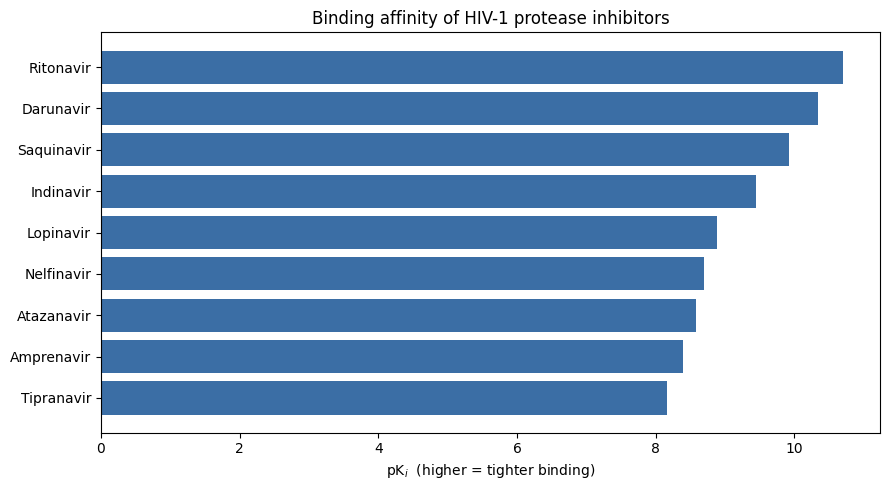

In [4]:
# Visualize binding affinity across the drug class
plot_df = df.dropna(subset=["pKi"]).sort_values("pKi", ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["Drug"], plot_df["pKi"], color="#3b6ea5")
plt.xlabel("pK$_i$  (higher = tighter binding)")
plt.title("Binding affinity of HIV-1 protease inhibitors")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Section 3 — Ligand Efficiency

Ligand efficiency (LE) is a metric that assesses the binding affinity of a compound relative to its size. It helps in identifying compounds that achieve good binding with minimal molecular weight or number of heavy atoms, which is often desirable in drug design to improve properties like permeability and solubility.

There are several ways to define ligand efficiency. Two common ones are:

1.  **Ligand Efficiency (LE)**:
    `LE = pK_i / n_heavy_atoms`
    Where `n_heavy_atoms` is the number of non-hydrogen atoms.

2.  **Binding Efficiency Index (BEI)** (sometimes referred to as LE per molecular weight):
    `BEI = pK_i / MW`
    Where `MW` is the molecular weight.

We will calculate LE using the number of heavy atoms, as it's often more directly related to the 'size' contribution to binding.

In [5]:
# Calculate Ligand Efficiency (LE)
df["LE"] = df["pKi"] / df["HeavyAtoms"]

display(df[["Drug", "pKi", "HeavyAtoms", "LE"]].sort_values("LE", ascending=False))

,Drug,pKi,HeavyAtoms,LE
9,Darunavir,10.346787,38,0.272284
4,Amprenavir,8.397940,35,0.239941
3,Nelfinavir,8.698970,40,0.217474
1,Ritonavir,10.698970,50,0.213979
2,Indinavir,9.443697,45,0.209860
0,Saquinavir,9.920819,49,0.202466
8,Tipranavir,8.167491,42,0.194464
5,Lopinavir,8.886057,46,0.193175
6,Atazanavir,8.585027,51,0.168334
7,Fosamprenavir,NaN,39,NaN


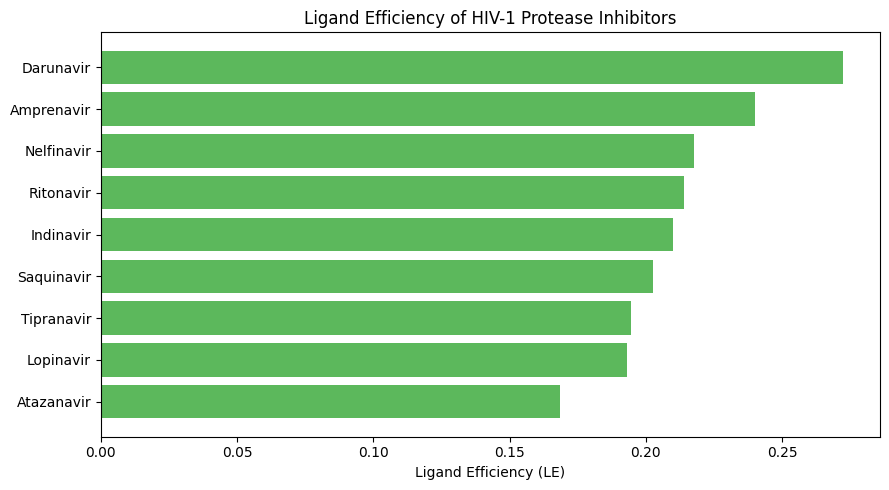

In [8]:
# Visualize Ligand Efficiency across the drug class
plot_le_df = df.dropna(subset=["LE"]).sort_values("LE", ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(plot_le_df["Drug"], plot_le_df["LE"], color="#5cb85c")
plt.xlabel("Ligand Efficiency (LE)")
plt.title("Ligand Efficiency of HIV-1 Protease Inhibitors")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Section 4 — Druglikeness: Lipinski's Rule of Five

Binding tightly to the target is necessary but *not sufficient* for a good oral drug. The molecule also has to be absorbed, distributed, and not immediately excreted or degraded. Christopher Lipinski's famous **"Rule of Five"** (1997) is a quick, rough filter for whether a molecule is likely to be **orally bioavailable**. A compound is flagged as having *worse* oral druglikeness if it violates more than one of:

| Rule | Threshold |
|---|---|
| Molecular weight | ≤ 500 g/mol |
| LogP (lipophilicity) | ≤ 5 |
| H-bond donors | ≤ 5 |
| H-bond acceptors | ≤ 10 |

(Two commonly-added extensions, sometimes called "Rule of Five and a half": rotatable bonds ≤ 10, and polar surface area ≤ 140 Å². We'll just use rotatable bonds ≤ 10 here since we have that column.)


In [13]:
def lipinski_violations(row):
    violations = {
        "MW>500": row["MW"] > 500,
        "LogP>5": row["LogP"] > 5,
        "HBD>5": row["HBD"] > 5,
        "HBA>10": row["HBA"] > 10,
        "RotBonds>10": row["RotBonds"] > 10,
    }
    return violations

def count_violations(row):
    v = lipinski_violations(row)
    return sum(v.values())

df["Lipinski_Violations"] = df.apply(count_violations, axis=1)
df["Druglike"] = df["Lipinski_Violations"] <= 1   # standard cutoff: 1 violation still OK

df[["Drug", "MW", "LogP", "HBD", "HBA", "RotBonds", "Lipinski_Violations", "Druglike"]] \
    .sort_values("Lipinski_Violations")

,Drug,MW,LogP,HBD,HBA,RotBonds,Lipinski_Violations,Druglike
4,Amprenavir,505.63,2.5,3,6,10,1,True
9,Darunavir,547.66,1.8,3,7,8,1,True
6,Atazanavir,704.86,4.5,4,9,15,2,False
0,Saquinavir,670.85,3.3,3,8,13,2,False
7,Fosamprenavir,585.63,0.3,4,9,12,2,False
2,Indinavir,613.79,2.8,3,5,11,2,False
3,Nelfinavir,567.78,5.5,3,4,11,3,False
1,Ritonavir,720.94,5.9,3,8,18,3,False
5,Lopinavir,628.80,5.9,4,5,15,3,False
8,Tipranavir,602.67,6.9,3,5,11,3,False


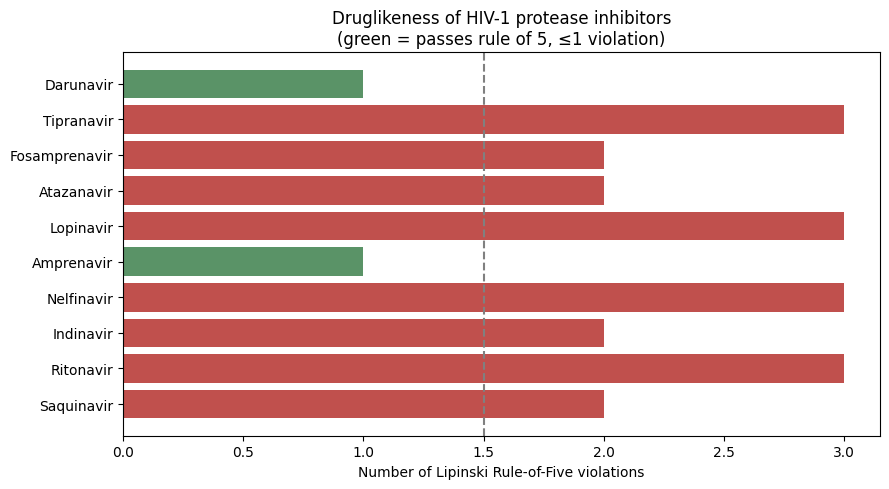

In [14]:
plt.figure(figsize=(9, 5))
colors = df["Druglike"].map({True: "#5a9367", False: "#c0504d"})
plt.barh(df["Drug"], df["Lipinski_Violations"], color=colors)
plt.axvline(1.5, color="gray", linestyle="--")
plt.xlabel("Number of Lipinski Rule-of-Five violations")
plt.title("Druglikeness of HIV-1 protease inhibitors\n(green = passes rule of 5, ≤1 violation)")
plt.tight_layout()
plt.show()

## Section 5 — Evaluate which drug is "best"?

This is the heart of real drug discovery: **potency and druglikeness are often in tension.** A chemist can frequently buy more potency by adding more atoms/polar groups — but that often makes the molecule bigger, greasier, or more flexible, hurting oral druglikeness. The "best" drug depends on what you're optimizing for (raw potency? oral convenience? resistance profile? manufacturability?).

Let's put both axes on one plot.


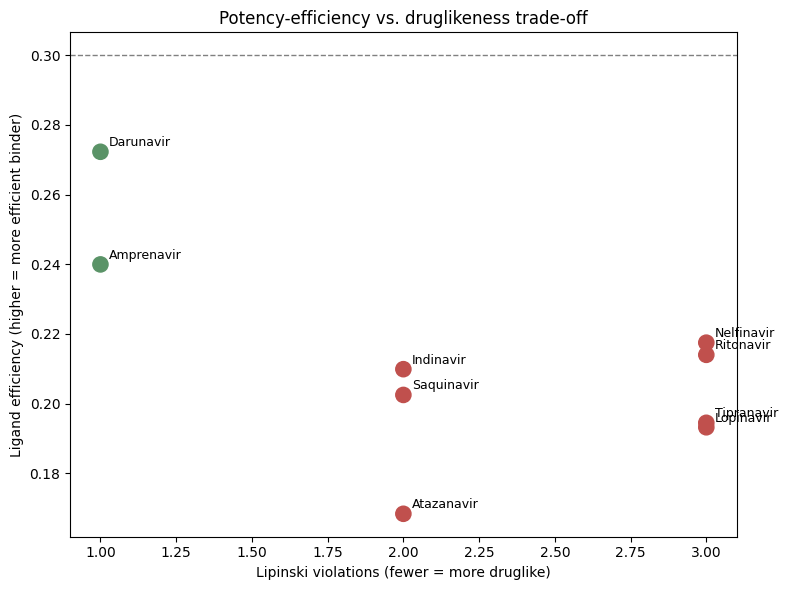

In [15]:
plot_df2 = df.dropna(subset=["LE"])

plt.figure(figsize=(8, 6))
plt.scatter(plot_df2["Lipinski_Violations"], plot_df2["LE"],
            s=120, c=plot_df2["Druglike"].map({True: "#5a9367", False: "#c0504d"}))

for _, row in plot_df2.iterrows():
    plt.annotate(row["Drug"], (row["Lipinski_Violations"], row["LE"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=9)

plt.axhline(0.3, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Lipinski violations (fewer = more druglike)")
plt.ylabel("Ligand efficiency (higher = more efficient binder)")
plt.title("Potency-efficiency vs. druglikeness trade-off")
plt.tight_layout()
plt.show()